In [6]:
# Standard Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-learn Libraries
from sklearn.datasets import fetch_covtype
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, log_loss
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# PyTorch Core
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch import Tensor
from torch.autograd import Function

# PyTorch Utilities
import torch.utils.benchmark as benchmark
import torch._dynamo
from torch.optim import Optimizer

# PyTorch Model Utilities
from torchinfo import summary

In [7]:
def zeropower_via_newtonschulz5(G: Tensor, steps: int) -> Tensor:
    assert G.ndim >= 2
    a, b, c = 3.4445, -4.7750, 2.0315
    X = G.clone().float()
    if G.size(-2) > G.size(-1):
        X = X.mT
    X = X / (X.norm(dim=(-2, -1), keepdim=True) + 1e-7)
    for _ in range(steps):
        A = X @ X.mT
        B = b * A + c * A @ A
        X = a * X + B @ X
    if G.size(-2) > G.size(-1):
        X = X.mT
    return X

class Muon(Optimizer):
    def __init__(self, params, lr=0.02, weight_decay=0.01, momentum=0.95, nesterov=True, ns_steps=5):
        defaults = dict(lr=lr, weight_decay=weight_decay, momentum=momentum, nesterov=nesterov, ns_steps=ns_steps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self):
        for group in self.param_groups:
            lr = group["lr"]
            weight_decay = group["weight_decay"]
            momentum = group["momentum"]
            nesterov = group["nesterov"]
            ns_steps = group["ns_steps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad.data

                if g.ndim < 2:
                    continue  # skip scalars, biases, etc.

                state = self.state[p]
                if "momentum_buffer" not in state:
                    state["momentum_buffer"] = torch.zeros_like(g)

                buf = state["momentum_buffer"]
                buf.mul_(momentum).add_(g)

                if nesterov:
                    g = g + momentum * buf
                else:
                    g = buf

                if g.ndim == 4:
                    g = g.view(g.size(0), -1)

                g = zeropower_via_newtonschulz5(g, steps=ns_steps).view_as(p)

                p.mul_(1 - lr * weight_decay)
                p.add_(g, alpha=-lr)

In [8]:
torch._dynamo.config.cache_size_limit = 16

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
device = "cpu"

In [9]:
df = sns.load_dataset('diamonds')
df = df[['carat', 'depth', 'table', 'price', 'x', 'y', 'z', 'cut']]

df['cut'] = (df['cut'] == 'Ideal').astype(int)

X = df.drop('cut', axis=1)
y = df['cut']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long).to(device)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long).to(device)

print(X.shape)
print(y.shape)

ideal_percentage = df['cut'].mean() * 100
print(f"Percentage of diamonds with 'Ideal' cut: {ideal_percentage:.2f}%")

model = LogisticRegression(penalty='l2', C=0.001, max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

y_pred_proba = model.predict_proba(X_test)
loss = log_loss(y_test, y_pred_proba)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Not Ideal', 'Ideal']))
print(model.coef_)
print(f"Log Loss: {loss:.6f}")

(53940, 7)
(53940,)
Percentage of diamonds with 'Ideal' cut: 39.95%
Test Accuracy: 79.30%
Classification Report:
              precision    recall  f1-score   support

   Not Ideal       0.82      0.85      0.83      6496
       Ideal       0.75      0.71      0.73      4292

    accuracy                           0.79     10788
   macro avg       0.79      0.78      0.78     10788
weighted avg       0.79      0.79      0.79     10788

[[-0.15688782 -0.46189194 -1.57368125  0.22509094 -0.08309788 -0.03167662
  -0.08671039]]
Log Loss: 0.451068


/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/nhatt/Downloads/All_Mac/Code/ML_experiments/.venv/lib/python3.11/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered

In [10]:
def train(model, criterion, optimizers):
    print(summary(model, input_data=X_train_tensor))

    torch.set_printoptions(threshold=float('inf'))
    for name, param in model.named_parameters():
        print(name)
        print(param)

    @torch._dynamo.explain
    def run_model(x):
        return model(x)

    run_model(X_train_tensor) # type: ignore

    epochs = 10000
    best_test_loss = float('inf')

    train_losses = []
    test_losses = []

    for epoch in range(epochs):
        model.train()
        for opt in optimizers:
            opt.zero_grad()

        train_outputs = model(X_train_tensor)
        train_loss = criterion(train_outputs, y_train_tensor)
        train_loss.backward()

        for opt in optimizers:
            opt.step()

        model.eval()
        with torch.no_grad():
            test_outputs = model(X_test_tensor)
            test_loss = criterion(test_outputs, y_test_tensor)
            test_predictions = torch.argmax(test_outputs, dim=1)
            test_accuracy = (test_predictions == y_test_tensor).sum().item() / y_test_tensor.size(0)

        train_losses.append(train_loss.item())
        test_losses.append(test_loss.item())

        if test_loss.item() < best_test_loss:
            best_test_loss = test_loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.8f}, Test Loss: {test_loss.item():.8f}, Test Accuracy: {test_accuracy:.4f}")

    print()
    print(f"Lowest Test Loss: {best_test_loss:.8f}")

    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Test Loss Over Epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

In [41]:
class CReLUFunction(Function):
    @staticmethod
    def forward(ctx, input):
        ctx.save_for_backward(input)
        pos = torch.relu(input)
        neg = torch.relu(-input)
        return torch.cat((pos, neg), dim=1)

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors

        channels = input.shape[1]
        grad_pos = grad_output[:, :channels]
        grad_neg = grad_output[:, channels:]

        grad_input = grad_pos * (input > 0).float() - grad_neg * (input < 0).float()
        
        return grad_input

In [42]:
class CReLU(nn.Module):
    def forward(self, x):
        return CReLUFunction.apply(x)

In [43]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=4):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))

        self.bns = nn.ModuleList()
        self.linears = nn.ModuleList()
        for i in range(num_layers):
            if i % 2 == 0:
                self.linears.append(nn.Linear(n, n * 4, bias=False))
                self.bns.append(nn.BatchNorm1d(n * 4))
            else:
                self.linears.append(nn.Linear(n * 4, n, bias=False))
                self.bns.append(nn.BatchNorm1d(n))

        self.final = nn.Linear(n, 2)

    def forward(self, x):
        for linear, bn in zip(self.linears, self.bns):
            x = F.relu(bn(linear(x)))

        return self.final(x)

In [24]:
model = (DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters():
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

Muon parameters:
torch.Size([28, 7])
torch.Size([7, 28])
torch.Size([28, 7])
torch.Size([7, 28])
torch.Size([2, 7])

AdamW parameters:
torch.Size([7])
torch.Size([28])
torch.Size([28])
torch.Size([7])
torch.Size([7])
torch.Size([28])
torch.Size([28])
torch.Size([7])
torch.Size([7])
torch.Size([2])


Layer (type:depth-idx)                   Output Shape              Param #
DiamondNN                                [43152, 2]                7
├─ModuleList: 1-7                        --                        (recursive)
│    └─Linear: 2-1                       [43152, 28]               196
├─ModuleList: 1-8                        --                        (recursive)
│    └─BatchNorm1d: 2-2                  [43152, 28]               56
├─ModuleList: 1-7                        --                        (recursive)
│    └─Linear: 2-3                       [43152, 7]                196
├─ModuleList: 1-8                        --                        (recursive)
│    └─BatchNorm1d: 2-4                  [43152, 7]                14
├─ModuleList: 1-7                        --                        (recursive)
│    └─Linear: 2-5                       [43152, 28]               196
├─ModuleList: 1-8                        --                        (recursive)
│    └─BatchNorm1d: 2-6      

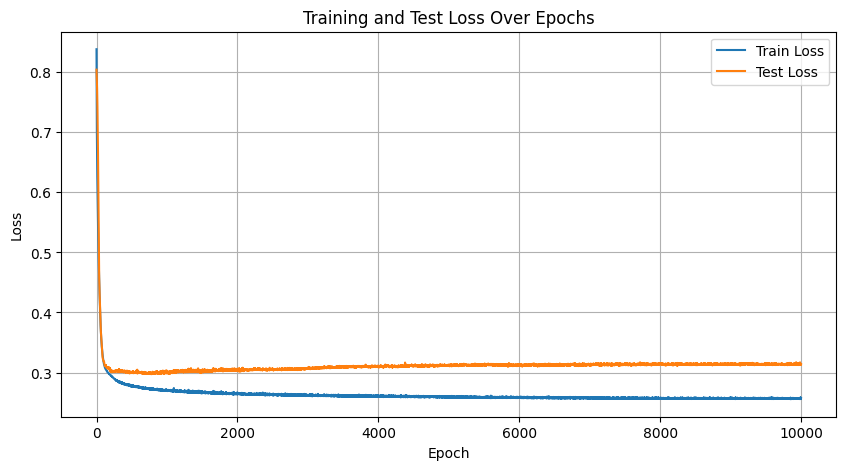

In [25]:
train(model, criterion, optimizers)

In [56]:
class DiamondNN(nn.Module):
    def __init__(self, n, num_layers=4):
        super().__init__()
        self.bias = torch.nn.Parameter(torch.zeros(n))
        self.activation = CReLU()

        self.bns = nn.ModuleList()
        self.linears = nn.ModuleList()
        for i in range(num_layers):
            if i % 2 == 0:
                self.linears.append(nn.Linear(n * 2, n * 2, bias=False))
                self.bns.append(nn.BatchNorm1d(n * 2))
            else:
                self.linears.append(nn.Linear(n * 4, n, bias=False))
                self.bns.append(nn.BatchNorm1d(n))

        self.final = nn.Linear(n * 2, 2)

    def forward(self, x):
        x = self.activation(x)
        
        for linear, bn in zip(self.linears, self.bns):
            x = self.activation(bn(linear(x)))

        return self.final(x)

In [57]:
model = (DiamondNN(n=X.shape[1]).to(device))
criterion = nn.CrossEntropyLoss()

muon_params = []
adamw_params = []

for name, param in model.named_parameters():
    if (param.ndim >= 2):
        muon_params.append(param)
    else:
        adamw_params.append(param)

print("Muon parameters:")
for p in muon_params:
    print(p.shape)

print()
print("AdamW parameters:")
for p in adamw_params:
    print(p.shape)

optimizers = [
    Muon(muon_params, lr=0.01, weight_decay=0.0),
    optim.AdamW(adamw_params, weight_decay=0.0)
]

Muon parameters:
torch.Size([14, 14])
torch.Size([7, 28])
torch.Size([14, 14])
torch.Size([7, 28])
torch.Size([2, 14])

AdamW parameters:
torch.Size([7])
torch.Size([14])
torch.Size([14])
torch.Size([7])
torch.Size([7])
torch.Size([14])
torch.Size([14])
torch.Size([7])
torch.Size([7])
torch.Size([2])


Layer (type:depth-idx)                   Output Shape              Param #
DiamondNN                                [43152, 2]                7
├─CReLU: 1-1                             [43152, 14]               --
├─ModuleList: 1-11                       --                        (recursive)
│    └─Linear: 2-1                       [43152, 14]               196
├─ModuleList: 1-12                       --                        (recursive)
│    └─BatchNorm1d: 2-2                  [43152, 14]               28
├─CReLU: 1-4                             [43152, 28]               --
├─ModuleList: 1-11                       --                        (recursive)
│    └─Linear: 2-3                       [43152, 7]                196
├─ModuleList: 1-12                       --                        (recursive)
│    └─BatchNorm1d: 2-4                  [43152, 7]                14
├─CReLU: 1-7                             [43152, 14]               --
├─ModuleList: 1-11                       --     

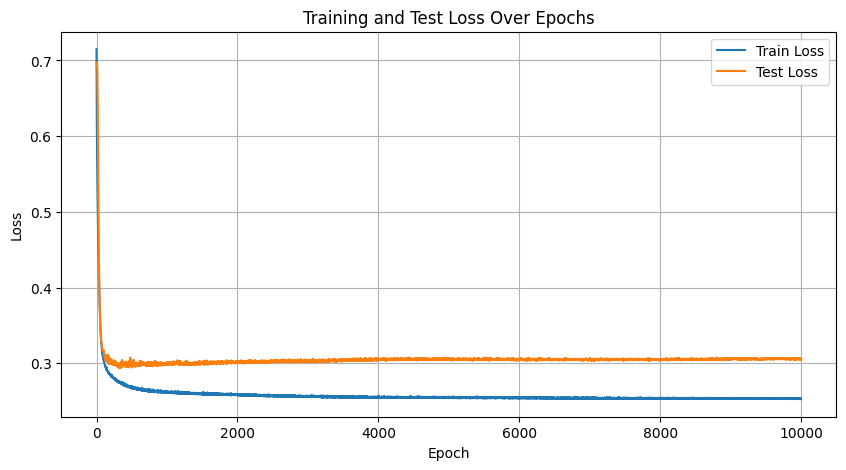

In [58]:
train(model, criterion, optimizers)